# Part 2: Wind Energy Production [40 pts]

Selected turbines: **BAR LowSP 6.5MW** and **IEA 10MW RWT**.

In [1]:
import sys
sys.path.append("../../src")  # lets `import windtools` work with plain python, no install needed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from windtools import power_curve, wind_profile, wake

bar = power_curve.load_power_curve("../../data/turbines/BAR_LowSP_6.5MW_234.csv")
iea10 = power_curve.load_power_curve("../../data/turbines/IEA_10MW_198_RWT.csv")
iea15 = power_curve.load_power_curve("../../data/turbines/IEA_15MW_240_RWT.csv")

TURBINES = {
    "BAR_6.5MW": {"curve": bar, "hub_height": 150, "rotor_diameter": 234, "rated_power_kw": 6500, "cut_in": 4, "cut_out": 25},
    "IEA_10MW": {"curve": iea10, "hub_height": 119, "rotor_diameter": 198, "rated_power_kw": 10000, "cut_in": 4, "cut_out": 25},
    "IEA_15MW": {"curve": iea15, "hub_height": 150, "rotor_diameter": 240, "rated_power_kw": 15000, "cut_in": 3, "cut_out": 25},
}

SELECTED = ["BAR_6.5MW", "IEA_10MW"]

## Power curves of the two selected turbines [5 pts]

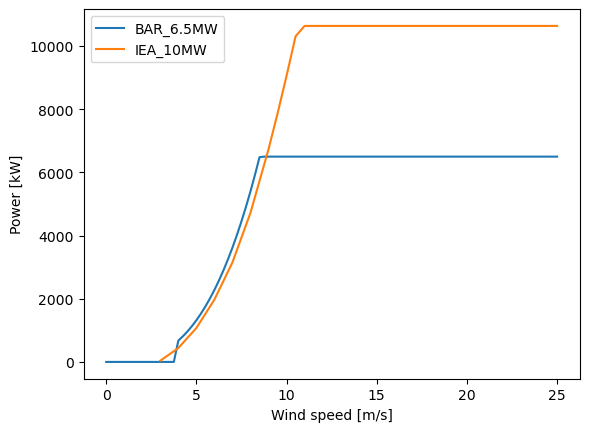

In [2]:
for name in SELECTED:
    df = TURBINES[name]["curve"]
    plt.plot(df.iloc[:, 0], df.iloc[:, 1], label=name)
plt.xlabel("Wind speed [m/s]"); plt.ylabel("Power [kW]"); plt.legend()

## Extrapolate wind speed to hub height (log law) [10 pts]

Use the 10 m and 50 m NASA POWER wind speed series to estimate the roughness length z0, then extrapolate to each turbine's hub height.

In [3]:
df_wind = pd.read_csv("../../data/wind/POWER_Point_Hourly_20250101_20251231_054d09N_003d74W_LST.csv", skiprows=10)
wind_10m = df_wind["WS10M"].to_numpy()
wind_50m = df_wind["WS50M"].to_numpy()

z0 = wind_profile.roughness_length(wind_10m.mean(), 10, wind_50m.mean(), 50)
print(f"Roughness length z0 = {z0:.5f} m")

hub_height_speeds = {
    name: wind_profile.extrapolate_log_law(wind_10m, 10, info["hub_height"], z0)
    for name, info in TURBINES.items()
}
for name in SELECTED:
    print(f"{name}: mean hub-height speed = {hub_height_speeds[name].mean():.3f} m/s")

Roughness length z0 = 0.00334 m
BAR_6.5MW: mean hub-height speed = 9.238 m/s
IEA_10MW: mean hub-height speed = 9.038 m/s


## Annual Energy Yield (AEY) and Capacity Factor (CF) [10 pts]

In [4]:
for name in SELECTED:
    info = TURBINES[name]
    aey = power_curve.annual_energy_yield(info["curve"], hub_height_speeds[name], cut_in=info["cut_in"], cut_out=info["cut_out"])
    cf = power_curve.capacity_factor(aey, info["rated_power_kw"])
    info["AEY_MWh"], info["CF"] = aey, cf
    print(f"{name}: AEY = {aey:.0f} MWh, CF = {cf:.3f}")

BAR_6.5MW: AEY = 39419 MWh, CF = 0.692
IEA_10MW: AEY = 52186 MWh, CF = 0.596


## Wake array efficiency (Jensen model, 3 turbines in a row, 6D spacing, k = 0.038) [10 pts]

In [5]:
# Only the IEA_10MW power curve file includes a Ct column, so the wake
# array analysis uses this turbine (its hub-height mean wind speed as inflow).
turbine = TURBINES["IEA_10MW"]
radius = turbine["rotor_diameter"] / 2
spacing = 6 * turbine["rotor_diameter"]
U_mean = hub_height_speeds["IEA_10MW"].mean()

power_func = lambda u: power_curve.power_at(turbine["curve"], u, cut_in=turbine["cut_in"], cut_out=turbine["cut_out"])
ct_func = lambda u: power_curve.ct_at(turbine["curve"], u)

efficiency, speeds, powers = wake.array_efficiency(U_mean, power_func, ct_func, radius, spacing, k=0.038, n_turbines=3)
print(f"Inflow speed U = {U_mean:.3f} m/s")
print(f"Per-turbine inflow speeds: {[f'{s:.3f}' for s in speeds]} m/s")
print(f"Per-turbine power: {[f'{p:.1f}' for p in powers]} kW")
print(f"Array efficiency = {efficiency:.3f}")

Inflow speed U = 9.038 m/s
Per-turbine inflow speeds: ['9.038', '6.563', '4.497'] m/s
Per-turbine power: ['6821.5', '2637.1', '755.5'] kW
Array efficiency = 0.499


## Turbine recommendation [5 pts]

TODO: justify which of the two selected turbines fits the site best.